# Renovation Quote Analysis & Cost Prediction

*Portfolio demo - synthetic data only.*

This notebook (1) explores a synthetic dataset of **800 renovation quotes** and
(2) trains models to **predict the final quote price** from a simple building
survey (floor area, floor level, elevator, building age, condition).

The dataset is produced by the project's own object-oriented costing engine, so
the analysis and the Streamlit app share a single source of truth.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

DOCS = Path("docs")
DOCS.mkdir(exist_ok=True)

df = pd.read_csv("data/quotes_sample.csv")
print("dataset:", df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


dataset: (800, 20)


,area_ping,floor,has_elevator,building_age,condition,difficulty_multiplier,cost_demolition,cost_plumbing,cost_electrical,cost_carpentry,cost_flooring,cost_painting,cost_bathroom,cost_kitchen,trade_subtotal,supervision_fee,grand_total,monthly_rent,net_yield,payback_months
0,41.4,10,False,25,aging,1.40,30427,63867,128364,163269,169797,167332,119746,106327,949129,94913,1044042,40400,0.3970,30.2
1,42.6,13,True,23,aging,1.05,32960,45692,101262,162544,147762,102464,103596,94162,790442,79044,869487,36600,0.4319,27.8
2,18.1,14,True,29,aging,1.05,11762,18865,43443,59856,56396,47584,44253,53086,335245,33524,368769,14300,0.3979,30.2
3,47.2,15,True,33,aging,1.15,33421,97690,98054,187186,147982,162233,129472,125354,981392,98139,1079531,42700,0.4058,29.6
4,13.7,5,False,25,poor,1.20,13010,24025,49557,58899,57860,54693,34085,36101,328230,32823,361053,11900,0.3382,35.5


## 1. Dataset overview

Each row is one renovated unit: the **survey inputs**, the derived difficulty
multiplier, the **cost per trade**, the pricing totals, and rental-yield
metrics.

In [2]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
area_ping,800.0,31.34,10.82,12.10,21.98,31.25,40.52,49.90
floor,800.0,7.96,4.25,1.00,4.00,8.00,12.00,15.00
building_age,800.0,28.68,14.95,3.00,16.00,28.00,42.00,54.00
difficulty_multiplier,800.0,1.16,0.14,1.00,1.05,1.10,1.20,1.50
cost_demolition,800.0,24190.91,9427.38,6886.00,16845.75,23246.50,31071.50,60541.00
cost_plumbing,800.0,45604.89,17872.47,13233.00,31325.50,43548.50,57810.75,106526.00
cost_electrical,800.0,84342.18,32589.40,26964.00,58492.75,81876.00,107863.25,190069.00
cost_carpentry,800.0,119625.60,46518.60,31774.00,82646.25,114579.00,154030.25,281349.00
cost_flooring,800.0,128435.77,50546.26,36231.00,88861.00,121726.00,163527.50,309058.00
cost_painting,800.0,106311.91,42753.89,31756.00,71670.00,101171.50,135105.00,290705.00


## 2. Exploratory data analysis (EDA)

> **EDA** = getting to know the data before modeling: distributions, group
> differences, and relationships between variables.

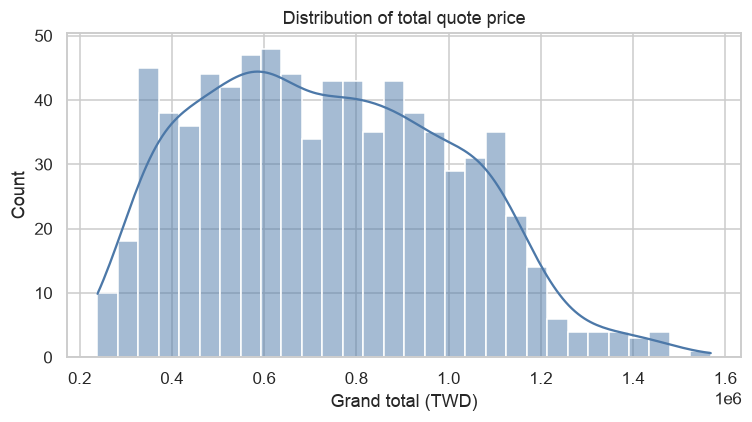

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["grand_total"], bins=30, kde=True, color="#4C78A8", ax=ax)
ax.set_title("Distribution of total quote price")
ax.set_xlabel("Grand total (TWD)")
fig.tight_layout()
fig.savefig(DOCS / "eda_total_distribution.png", bbox_inches="tight")
plt.show()

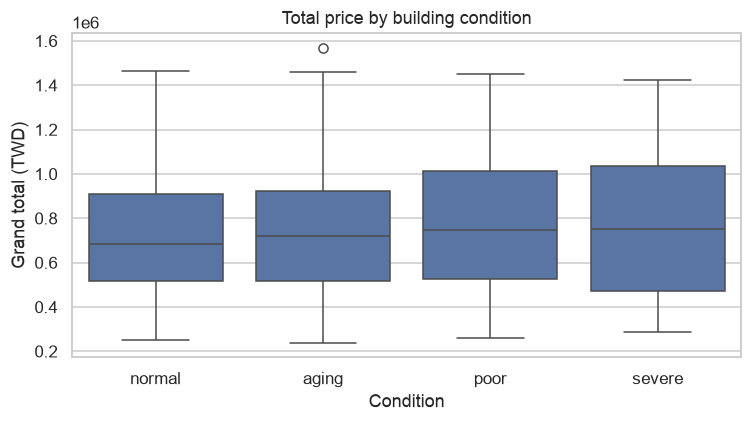

In [4]:
order = ["normal", "aging", "poor", "severe"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="condition", y="grand_total", order=order, ax=ax)
ax.set_title("Total price by building condition")
ax.set_xlabel("Condition")
ax.set_ylabel("Grand total (TWD)")
fig.tight_layout()
fig.savefig(DOCS / "eda_price_by_condition.png", bbox_inches="tight")
plt.show()

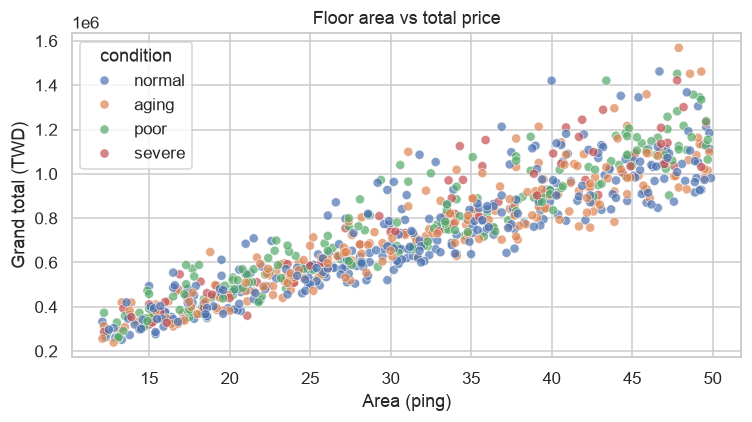

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=df, x="area_ping", y="grand_total", hue="condition",
                hue_order=order, alpha=0.7, ax=ax)
ax.set_title("Floor area vs total price")
ax.set_xlabel("Area (ping)")
ax.set_ylabel("Grand total (TWD)")
fig.tight_layout()
fig.savefig(DOCS / "eda_area_vs_total.png", bbox_inches="tight")
plt.show()

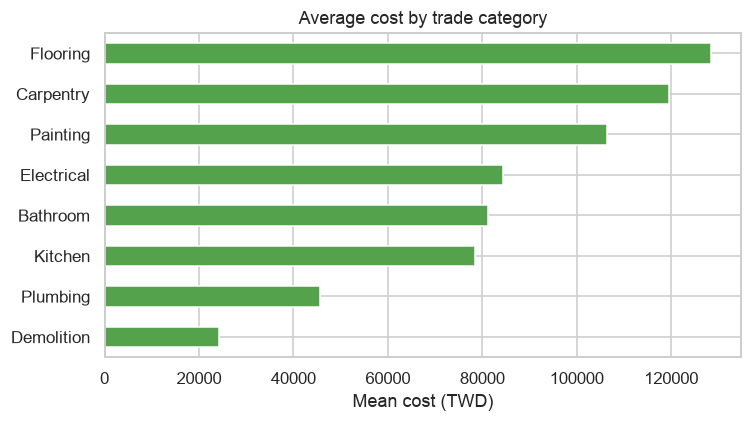

In [6]:
cost_cols = [c for c in df.columns if c.startswith("cost_")]
means = df[cost_cols].mean().sort_values()
means.index = [c.replace("cost_", "").title() for c in means.index]
fig, ax = plt.subplots(figsize=(7, 4))
means.plot(kind="barh", color="#54A24B", ax=ax)
ax.set_title("Average cost by trade category")
ax.set_xlabel("Mean cost (TWD)")
fig.tight_layout()
fig.savefig(DOCS / "eda_category_composition.png", bbox_inches="tight")
plt.show()

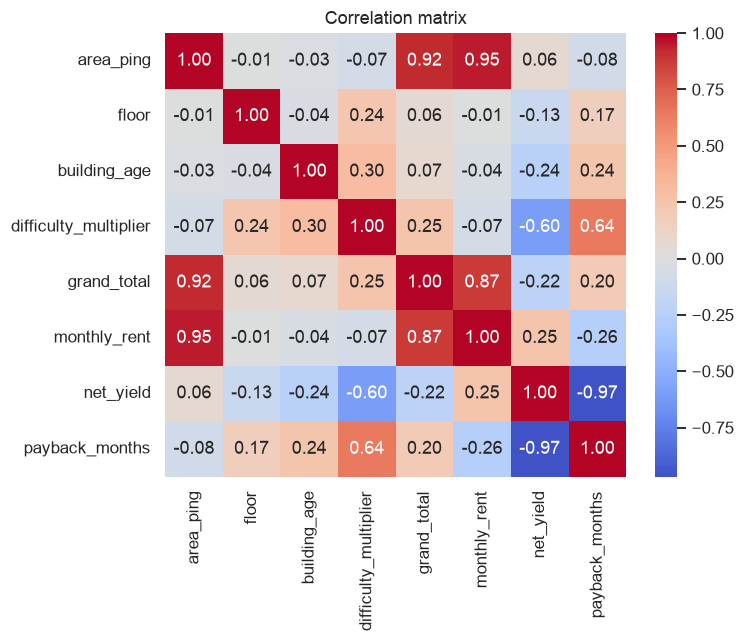

In [7]:
num_cols = ["area_ping", "floor", "building_age", "difficulty_multiplier",
            "grand_total", "monthly_rent", "net_yield", "payback_months"]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax)
ax.set_title("Correlation matrix")
fig.tight_layout()
fig.savefig(DOCS / "eda_correlation.png", bbox_inches="tight")
plt.show()

### What the EDA shows

- **Floor area is the dominant cost driver** - the strongest positive
  correlation with `grand_total`.
- **Worse condition shifts the whole price distribution up**, through the
  difficulty multiplier (normal -> severe).
- **Flooring, carpentry and painting** are the heaviest trade categories on
  average.
- `net_yield` falls as cost rises - a pricier renovation takes longer to pay
  back at a comparable rent.

## 3. Predicting the quote price

**Task:** given only a quick survey (area, floor, elevator, age, condition),
predict the final `grand_total`.

**Why it matters:** an instant ballpark for a salesperson, before the detailed
line-item quote is built.

In [8]:
from sklearn.model_selection import train_test_split

features = ["area_ping", "floor", "has_elevator", "building_age", "condition"]
X = pd.get_dummies(df[features], columns=["condition"], drop_first=True)
# get_dummies and the bool 'has_elevator' produce boolean columns -> cast to int
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)
y = df["grand_total"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("train:", X_train.shape, " test:", X_test.shape)
list(X.columns)

train: (640, 7)  test: (160, 7)


['area_ping',
 'floor',
 'has_elevator',
 'building_age',
 'condition_normal',
 'condition_poor',
 'condition_severe']

We hold out **20%** of the data as a test set (rows the model never sees in
training) and score with:

- **MAE** - mean absolute error in TWD ("on average we are off by ...").
- **RMSE** - root mean squared error; punishes big misses more.
- **R2** - share of price variance the model explains (1.0 = perfect).

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred),
    }, pred

lin_row, lin_pred = evaluate(LinearRegression(), "Linear Regression")
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf_row, rf_pred = evaluate(rf, "Random Forest")

results = (pd.DataFrame([lin_row, rf_row])
           .set_index("model")
           .round({"MAE": 0, "RMSE": 0, "R2": 3}))
results

,MAE,RMSE,R2
model,,,
Linear Regression,60855.0,78401.0,0.922
Random Forest,54340.0,71014.0,0.936


Both models explain the price well; the tree-based **Random Forest** captures
the multiplier interactions a little better. Since the ground-truth price is a
formula plus per-project noise, a flexible model gets close - the residual error
is essentially the quantity/price noise the survey features cannot see.

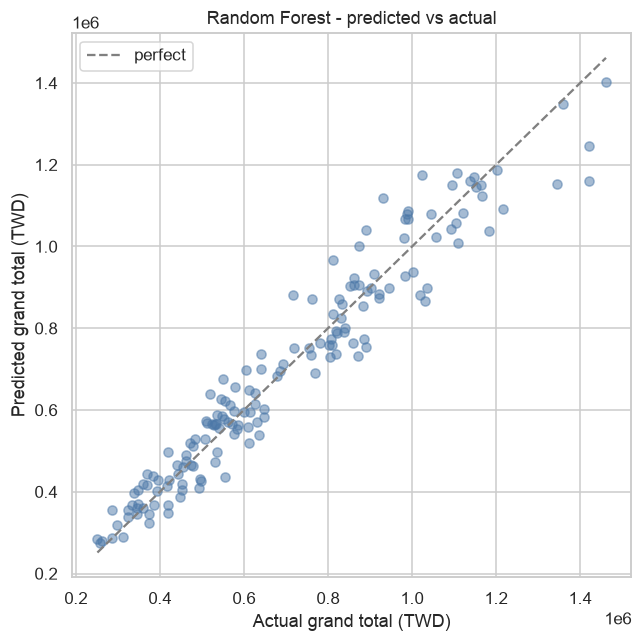

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, rf_pred, alpha=0.5, color="#4C78A8")
lims = [min(y_test.min(), rf_pred.min()), max(y_test.max(), rf_pred.max())]
ax.plot(lims, lims, "--", color="grey", label="perfect")
ax.set_xlabel("Actual grand total (TWD)")
ax.set_ylabel("Predicted grand total (TWD)")
ax.set_title("Random Forest - predicted vs actual")
ax.legend()
fig.tight_layout()
fig.savefig(DOCS / "model_pred_vs_actual.png", bbox_inches="tight")
plt.show()

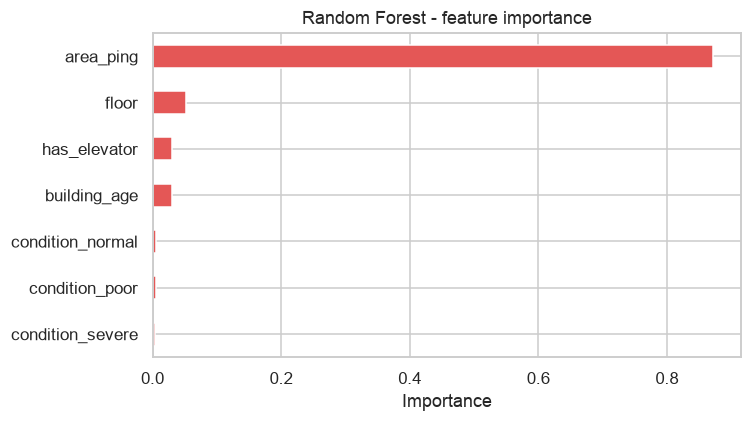

In [11]:
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importance.plot(kind="barh", color="#E45756", ax=ax)
ax.set_title("Random Forest - feature importance")
ax.set_xlabel("Importance")
fig.tight_layout()
fig.savefig(DOCS / "model_feature_importance.png", bbox_inches="tight")
plt.show()

## 4. Conclusion

- A simple survey predicts the renovation quote within a few percent - useful as
  an **instant ballpark** before the full line-item quote.
- **Floor area** and the **difficulty multiplier** (age/condition) are the
  biggest levers, matching domain intuition.
- **Rule engine vs model:** the app itself uses a transparent rule engine (fully
  explainable and auditable). This notebook shows how the same problem could be
  tackled with ML when the pricing rules are *unknown* and must be learned from
  historical quotes - the realistic scenario at a company with years of data.

**Next steps:** gradient boosting with cross-validation, prediction intervals,
and training on real historical quotes instead of synthetic data.